# Chapter 14 Lab — BOLD Physiology and the Hemodynamic Response (Python)

In this lab you will build the hemodynamic machinery that links neural activity to the BOLD signal — and then break it on purpose. We follow a four-step arc:

1. **Build the canonical HRF** as a difference of two gamma functions, and identify its peak and undershoot
2. **Simulate HRF variability** — a "young" versus an "elderly" hemodynamic response
3. **Treat the brain as a linear time-invariant (LTI) system**: convolve brief events and sustained epochs with the HRF, and verify scaling and superposition
4. **Break linearity**: add vascular saturation, map how refractory effects grow as events get closer together, and show that fitting a *linear* GLM to *saturating* data systematically biases amplitude estimates for densely spaced events

Because everything is simulated, you know the ground truth — so you can see exactly when the standard linear model is a good approximation and when it quietly misleads you.

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `scipy`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](https://torwager.github.io/elements-of-fmri-tutorials/book/part3/ch14-bold-physiology).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

rng = np.random.default_rng(14)   # reproducible noise

## 1. The canonical HRF: a difference of two gamma functions

A brief burst of neural activity evokes a stereotyped vascular response: a positive BOLD peak 5–7 seconds later, followed by an undershoot below baseline. A popular mathematical form is the **double-gamma** function — one gamma density creates the peak, and a second, later gamma is subtracted to create the undershoot:

::::{div}
:class: eq-tip
$$
h(t) = \frac{t^{\alpha_1 - 1}\,\beta_1^{\alpha_1}\, e^{-\beta_1 t}}{\Gamma(\alpha_1)} \;-\; c\,\frac{t^{\alpha_2 - 1}\,\beta_2^{\alpha_2}\, e^{-\beta_2 t}}{\Gamma(\alpha_2)}
$$
:::{div}
:class: eq-tip-text
h(t) — HRF amplitude at time t · t — time since neural activity (s) · α₁, β₁ — shape and rate of the peak gamma · α₂, β₂ — shape and rate of the undershoot gamma · c — undershoot amplitude · Γ — gamma function
:::
::::
:::{div}
:class: eq-where
*where* $h(t)$ *is the hemodynamic response at time* $t$ *(seconds since neural activity),* $\alpha_1$ *and* $\beta_1$ *are the shape and rate parameters of the gamma that creates the peak,* $\alpha_2$ *and* $\beta_2$ *those of the later gamma that creates the undershoot,* $c$ *the relative amplitude of the undershoot, and* $\Gamma(\cdot)$ *the gamma function that normalizes each term.*
:::

with SPM's default parameters $\alpha_1 = 6$, $\alpha_2 = 16$, $\beta_1 = \beta_2 = 1$, $c = 1/6$. We normalize so the peak equals 1 — from here on, "1 unit" means the peak response to a single brief event.

Peak at 5.0 s; undershoot minimum at 15.7 s (9% of peak amplitude)


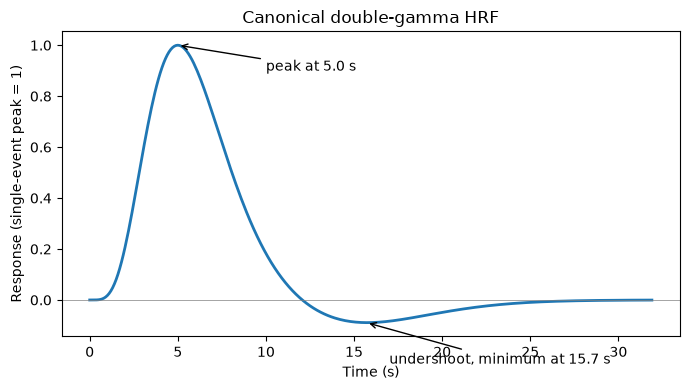

In [2]:
def double_gamma_hrf(t, a1=6.0, a2=16.0, b1=1.0, b2=1.0, c=1/6):
    """Canonical HRF: difference of two gamma densities (SPM default parameters)."""
    h = gamma.pdf(t, a1, scale=1/b1) - c * gamma.pdf(t, a2, scale=1/b2)
    return h / h.max()

dt = 0.1                          # time resolution (s)
t_hrf = np.arange(0, 32, dt)      # HRF time grid: 0-32 s
hrf = double_gamma_hrf(t_hrf)

peak_time = t_hrf[np.argmax(hrf)]
under_time = t_hrf[np.argmin(hrf)]

plt.figure(figsize=(7, 4))
plt.plot(t_hrf, hrf, lw=2)
plt.axhline(0, color="gray", lw=0.5)
plt.annotate(f"peak at {peak_time:.1f} s", (peak_time, 1.0), xytext=(10, 0.9),
             arrowprops=dict(arrowstyle="->"))
plt.annotate(f"undershoot, minimum at {under_time:.1f} s", (under_time, hrf.min()),
             xytext=(17, -0.25), arrowprops=dict(arrowstyle="->"))
plt.xlabel("Time (s)"); plt.ylabel("Response (single-event peak = 1)")
plt.title("Canonical double-gamma HRF")
plt.tight_layout()

print(f"Peak at {peak_time:.1f} s; undershoot minimum at {under_time:.1f} s "
      f"({100 * abs(hrf.min()):.0f}% of peak amplitude)")

The shape matches the physiology described in the chapter: the positive peak arrives ~5 s after neural activity (driven by the overcompensating inflow of oxygenated blood), and the post-stimulus undershoot reflects deoxyhemoglobin lingering while blood volume and metabolism return to baseline at different rates. Note that this canonical form omits the *initial dip* — the brief signal decrease in the first ~0.5 s — which is small (about one fifth of the peak at 3 T) and hard to detect at typical sampling rates.

## 2. The HRF is not fixed: simulating a "young" and an "elderly" response

The HRF varies across individuals, brain regions, and health states. With age — and with vascular conditions like hypertension or diabetes — the response becomes **lower in amplitude and more protracted**. We can mimic this by shifting the gamma parameters (later peak) and scaling down the amplitude.

Young: peak 5.0 s, amplitude 1.00
Old:   peak 7.0 s, amplitude 0.70


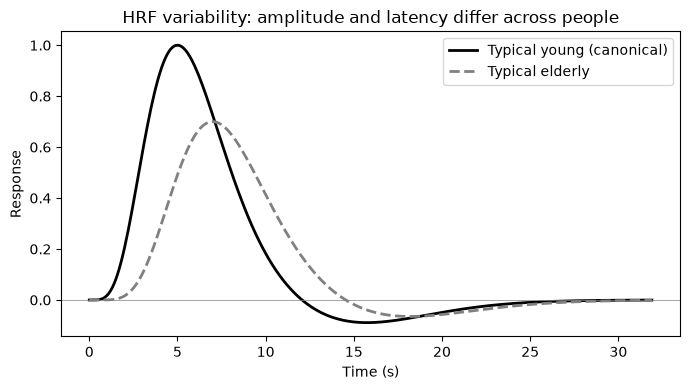

In [3]:
hrf_young = double_gamma_hrf(t_hrf)                      # canonical
hrf_old   = 0.7 * double_gamma_hrf(t_hrf, a1=8, a2=18)   # later peak (a1, a2 up), 70% amplitude

plt.figure(figsize=(7, 4))
plt.plot(t_hrf, hrf_young, "k-", lw=2, label="Typical young (canonical)")
plt.plot(t_hrf, hrf_old, "--", color="gray", lw=2, label="Typical elderly")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Response")
plt.title("HRF variability: amplitude and latency differ across people")
plt.legend(); plt.tight_layout()

print(f"Young: peak {t_hrf[np.argmax(hrf_young)]:.1f} s, amplitude {hrf_young.max():.2f}")
print(f"Old:   peak {t_hrf[np.argmax(hrf_old)]:.1f} s, amplitude {hrf_old.max():.2f}")

If you analyze both groups with the *same* canonical HRF, the mismatch for the elderly group reduces model fit and estimated amplitudes — a purely vascular difference that can masquerade as a neural one. Keep this in mind whenever groups differ in age, medication, caffeine use, or vascular health.

## 3. The brain as a linear time-invariant system

Under the LTI assumption, the predicted BOLD response to *any* stimulus sequence is the convolution of the neural stimulus function $s(t)$ with the HRF $h(t)$:

::::{div}
:class: eq-tip
$$
x(t) = (s \ast h)(t)
$$
:::{div}
:class: eq-tip-text
x(t) — predicted BOLD signal · s — neural stimulus function (1 during events, 0 elsewhere) · h — hemodynamic response function · ∗ — convolution
:::
::::
:::{div}
:class: eq-where
*where* $x(t)$ *is the predicted BOLD signal at time* $t$*,* $s(t)$ *the neural stimulus function (1 during stimulation, 0 elsewhere),* $h(t)$ *the hemodynamic response function, and* $\ast$ *denotes convolution.*
:::

Let's build a small toolkit — a stimulus generator and a linear BOLD predictor — and compare a **brief event** (0.5 s) with a **sustained epoch** (20 s).

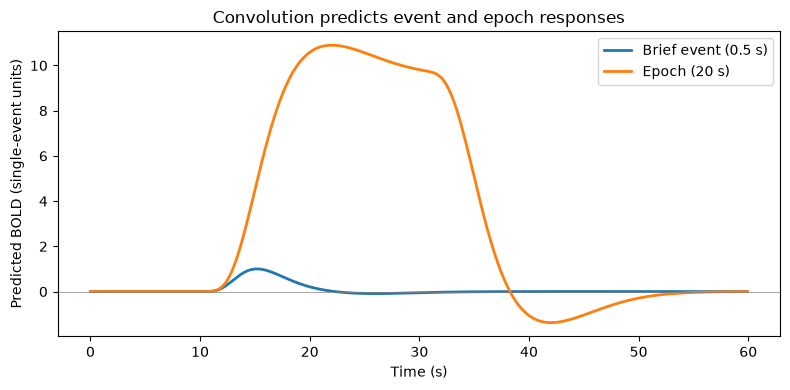

In [4]:
def stim(onsets, dur, length):
    """Boxcar stimulus function: 1 during each event, 0 elsewhere."""
    frame = np.arange(0, length, dt)
    s = np.zeros_like(frame)
    for o in np.atleast_1d(onsets):
        s[(frame >= o) & (frame < o + dur)] = 1.0
    return frame, s

def bold_linear(s):
    """LTI prediction: convolve stimulus with the canonical HRF."""
    return np.convolve(s, hrf)[:s.size] * dt

# Calibrate units: peak response to one 0.5 s event = 1
_, s_single = stim(10, 0.5, 60)
unit = bold_linear(s_single).max()

frame, s_brief = stim(10, 0.5, 60)     # brief event
_, s_epoch     = stim(10, 20, 60)      # sustained 20 s epoch

plt.figure(figsize=(8, 4))
plt.plot(frame, bold_linear(s_brief) / unit, lw=2, label="Brief event (0.5 s)")
plt.plot(frame, bold_linear(s_epoch) / unit, lw=2, label="Epoch (20 s)")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Predicted BOLD (single-event units)")
plt.title("Convolution predicts event and epoch responses")
plt.legend(); plt.tight_layout()

The brief event produces a transient copy of the HRF. The epoch response ramps up over ~10 s, plateaus (the vasculature reaches a steady state while stimulation continues), and returns to baseline — with an undershoot — after the epoch ends. This is why blocked designs yield large, sustained signals.

LTI systems have three defining properties. Let's verify two of them numerically: **scaling** (double the input, double the output) and **superposition** (the response to two events is the sum of the individual responses).

In [5]:
# Scaling: response to 2x the neural activity is exactly 2x the response
lhs = bold_linear(2 * s_brief)
rhs = 2 * bold_linear(s_brief)
print("Scaling holds:", np.allclose(lhs, rhs))

# Superposition: response to two events = sum of the two single-event responses
_, s_a  = stim(10, 0.5, 60)
_, s_b  = stim(22, 0.5, 60)
_, s_ab = stim([10, 22], 0.5, 60)
print("Superposition holds:", np.allclose(bold_linear(s_ab),
                                          bold_linear(s_a) + bold_linear(s_b)))

Scaling holds: True
Superposition holds: True


Both hold *exactly* — for the model. Real vasculature is another story, which brings us to the heart of this lab.

## 4. Breaking linearity: vascular saturation and refractory effects

Empirically, when stimuli of the same type repeat within a few seconds, responses to the later stimuli are **smaller than superposition predicts** — the vascular response saturates, and both neural and vascular refractory effects kick in. Linearity is a good approximation for events spaced ~5 s or more apart, but nonlinearities become substantial below ~2 s.

We model this with a compressive "squashing" function applied to the summed response — nearly linear for small responses, but flattening as the response approaches a ceiling:

::::{div}
:class: eq-tip
$$
\mathrm{sat}(x) = \kappa \, \tanh(x / \kappa)
$$
:::{div}
:class: eq-tip-text
sat(x) — saturated (observed) response · x — summed linear response (single-event units) · κ — vascular ceiling · tanh — hyperbolic tangent, a compressive squashing function
:::
::::
:::{div}
:class: eq-where
*where* $x$ *is the summed linear response (in single-event peak units),* $\kappa$ *is the vascular ceiling — the maximum response the local vasculature can produce — and* $\tanh$ *compresses the response smoothly toward that ceiling.*
:::

with ceiling $\kappa = 2$ single-event units. (CANlab's `onsets2fmridesign` implements the same idea with a piecewise-linear squash; see `hrf_saturation.m` in CanlabCore.)

Peak, linear prediction:  1.95
Peak, saturated response: 1.50


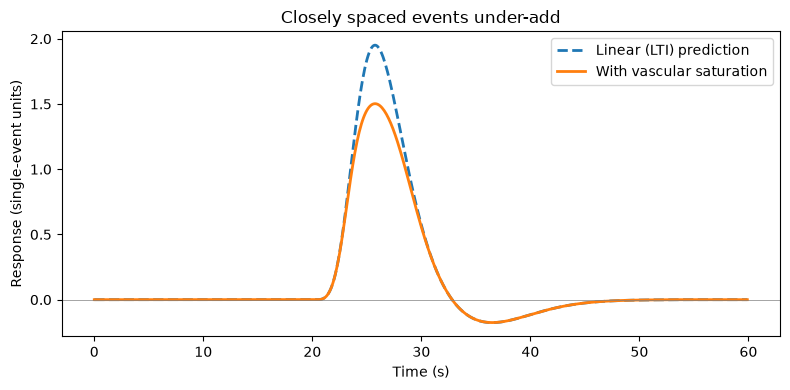

In [6]:
cap = 2.0                                # ceiling, in single-event peak units

def sat(x):
    """Compressive saturation: near-linear when small, squashed near the ceiling."""
    return cap * np.tanh(x / cap)

def bold_saturating(s):
    """'True' response: saturation applied to the summed linear prediction."""
    return sat(bold_linear(s) / unit)

# Two identical events, 1 s apart
frame, s_pair = stim([20, 21], 0.5, 60)
x_lin = bold_linear(s_pair) / unit

plt.figure(figsize=(8, 4))
plt.plot(frame, x_lin, "--", lw=2, label="Linear (LTI) prediction")
plt.plot(frame, sat(x_lin), lw=2, label="With vascular saturation")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Response (single-event units)")
plt.title("Closely spaced events under-add")
plt.legend(); plt.tight_layout()

print(f"Peak, linear prediction:  {x_lin.max():.2f}")
print(f"Peak, saturated response: {sat(x_lin).max():.2f}")

The linear model predicts the pair should peak near 2 units; the saturating system falls well short. Now let's map this out systematically: how much response does the **second** event add, as a function of the inter-stimulus interval (ISI)? We compute the marginal response to the second event — response to the pair minus response to a single event — and express it as a fraction of the single-event response.

ISI =  1.0 s -> second event evokes  76.0% of a full response
ISI =  2.0 s -> second event evokes  80.0% of a full response
ISI =  3.0 s -> second event evokes  85.4% of a full response
ISI =  4.0 s -> second event evokes  90.6% of a full response
ISI =  5.0 s -> second event evokes  94.8% of a full response
ISI =  6.0 s -> second event evokes  97.7% of a full response
ISI =  8.0 s -> second event evokes 100.6% of a full response
ISI = 10.0 s -> second event evokes 101.4% of a full response
ISI = 12.0 s -> second event evokes 101.3% of a full response


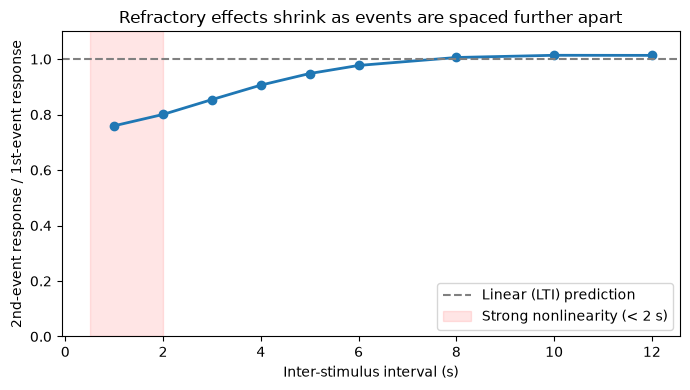

In [7]:
isis = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12])   # inter-stimulus intervals to test (s)
ratios = []

_, s_one = stim(20, 0.5, 90)                     # single 0.5 s event in a 90 s window
r_one = bold_saturating(s_one)

for isi in isis:
    _, s_two = stim([20, 20 + isi], 0.5, 90)
    r_two = bold_saturating(s_two)
    marginal = r_two - r_one                     # what the 2nd event adds
    ratios.append(marginal.sum() / r_one.sum())  # 1.0 = perfectly linear

ratios = np.array(ratios)

plt.figure(figsize=(7, 4))
plt.plot(isis, ratios, "o-", lw=2)
plt.axhline(1.0, color="gray", ls="--", label="Linear (LTI) prediction")
plt.axvspan(0.5, 2, color="red", alpha=0.10, label="Strong nonlinearity (< 2 s)")
plt.xlabel("Inter-stimulus interval (s)")
plt.ylabel("2nd-event response / 1st-event response")
plt.title("Refractory effects shrink as events are spaced further apart")
plt.ylim(0, 1.1); plt.legend(); plt.tight_layout()

for isi, r in zip(isis, ratios):
    print(f"ISI = {isi:4.1f} s -> second event evokes {100 * r:5.1f}% of a full response")

The pattern matches the empirical literature: for ISIs of roughly 5 s and beyond, the second response is close to full-sized and linearity is a reasonable working assumption; below ~2 s, the second event evokes a substantially reduced response.

## 5. Why this matters for analysis: saturation biases GLM estimates

Here is the practical sting. Suppose two conditions evoke *identical* neural responses per event, but one condition's events are **densely packed** (trains of 5 events, 2 s apart) while the other's are **sparse** (isolated events). We generate data from the *saturating* system, then fit the standard *linear* GLM. The linear regressor for the dense condition over-predicts the response during its trains, so ordinary least squares compensates by shrinking its beta.

*Demo adapted from the CANlab `nonlinear_saturation_bias_fmri` simulation (github.com/canlab).*

True per-event amplitude for BOTH conditions: 1.00 (by construction)

beta_sparse = 0.91
beta_dense  = 0.70

Spurious 'condition difference' (sparse - dense): 0.20


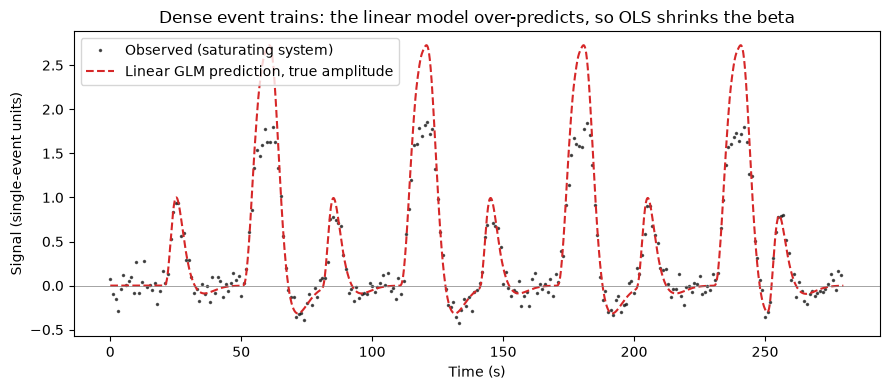

In [8]:
TR = 1.0        # sampling interval / repetition time (s)
length = 280.0  # simulated run length (s)

sparse_ons = [20, 80, 140, 200, 250]                       # 5 isolated events
train_starts = [50, 110, 170, 230]
dense_ons = [t0 + 2.0 * k for t0 in train_starts for k in range(5)]  # 4 trains of 5

frame, s_sparse = stim(sparse_ons, 0.5, length)
_, s_dense = stim(dense_ons, 0.5, length)

# Linear (LTI) regressors, as a standard GLM would build them
x_sparse = bold_linear(s_sparse) / unit
x_dense  = bold_linear(s_dense)  / unit

# 'True' data: same per-event amplitude (1 unit), but generated with saturation
y_true = bold_saturating(s_sparse + s_dense)

# Sample at the TR and add measurement noise
idx = np.arange(0, frame.size, int(round(TR / dt)))
X = np.column_stack([x_sparse[idx], x_dense[idx], np.ones(idx.size)])
y = y_true[idx] + 0.1 * rng.standard_normal(idx.size)   # noise SD = 0.1 single-event units

beta = np.linalg.lstsq(X, y, rcond=None)[0]

print("True per-event amplitude for BOTH conditions: 1.00 (by construction)\n")
print(f"beta_sparse = {beta[0]:.2f}")
print(f"beta_dense  = {beta[1]:.2f}")
print(f"\nSpurious 'condition difference' (sparse - dense): {beta[0] - beta[1]:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(frame[idx], y, "k.", ms=3, alpha=0.6, label="Observed (saturating system)")
plt.plot(frame, x_sparse + x_dense, "--", color="tab:red", lw=1.5,
         label="Linear GLM prediction, true amplitude")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Signal (single-event units)")
plt.title("Dense event trains: the linear model over-predicts, so OLS shrinks the beta")
plt.legend(); plt.tight_layout()

Both conditions have the same true per-event neural amplitude, yet the fitted GLM reports a smaller beta for the dense condition — a **systematic bias**, not noise, so it will not average away and will replicate beautifully across subjects. If your conditions differ in event density (rare oddballs vs. frequent standards, error trials vs. correct trials), a linear analysis can manufacture a "difference" out of pure vascular physiology.

**Remedies.** At the design stage: keep event density (spacing) comparable across the conditions you plan to compare, or keep ISIs ≥ ~5 s where linearity holds. At the modeling stage: compare the sparse condition against an equally sparse *subset* of the dense events, or use models that incorporate the nonlinearity explicitly.

## Explore on your own

1. **Severity of saturation.** Increase the ceiling (`cap = 4`) or decrease it (`cap = 1.2`) and re-run Sections 4–5. How does the size of the spurious condition difference change?
2. **Design fix.** Re-run Section 5 with dense-train spacing of 6 s instead of 2 s. How much of the bias disappears? What run length would you need to keep the same number of events?
3. **Modeling fix.** Build a regressor from only the *first* event of each dense train (matching the sparse condition's density) and compare its beta to the sparse condition's.
4. **HRF mismatch as a second bias.** Generate data using `hrf_old` (Section 2) but fit with regressors built from the canonical `hrf`. How much amplitude do you "lose" to shape mismatch — and could that difference be mistaken for reduced neural activity in older adults?